# CALVIN Dataset Exploration
Load a few data points, inspect their structure, and visualize first/last frames with action trajectories.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from config import (
    TRAIN_DIR, VAL_DIR, IMAGE_KEY, ACTION_KEY,
    EPISODE_TEMPLATE, LANG_ANNOTATIONS_SUBDIR, LANG_ANNOTATIONS_FILE,
)
from utils import load_calvin_to_dataframe, extract_verb
import os

## 1. Load language annotations into a DataFrame

In [2]:
df = load_calvin_to_dataframe(TRAIN_DIR)
print(f"Total annotated episodes: {len(df)}")
print(f"Unique verbs: {df['primary_verb'].nunique()}")
print()
df.head(10)

Processing language instructions with spaCy...
Filtered out 1720 examples that had 0 or >1 verbs.
Total annotated episodes: 3404
Unique verbs: 27



,start_idx,end_idx,instruction,verbs,primary_verb
0,315660,315724,move the door to the left side,[move],move
1,191730,191794,slide the door to the left side,[slide],slide
2,305439,305503,slide down the switch,[slide down],slide down
5,536830,536894,push the switch upwards,[push],push
7,80243,80307,open the cabinet drawer,[open],open
9,370674,370738,move up the switch,[move up],move up
10,526635,526699,pull the handle of the drawer,[pull],pull
11,485616,485680,move the sliding door to the left,[move],move
12,473791,473839,put the block in the drawer,[put],put
14,292365,292429,move the door to the right side,[move],move


## 2. Verb distribution

primary_verb
push          445
grasp         430
pick up       393
slide         293
rotate        290
left          195
lift          177
place         147
sweep         139
put           134
turn          132
move          106
turn off      100
stack          73
take off       46
lift up        40
remove         38
pull           35
store          34
close          32
open           30
unstack        24
go             18
collapse       18
slide down     13
move up        13
slide up        9
Name: count, dtype: int64



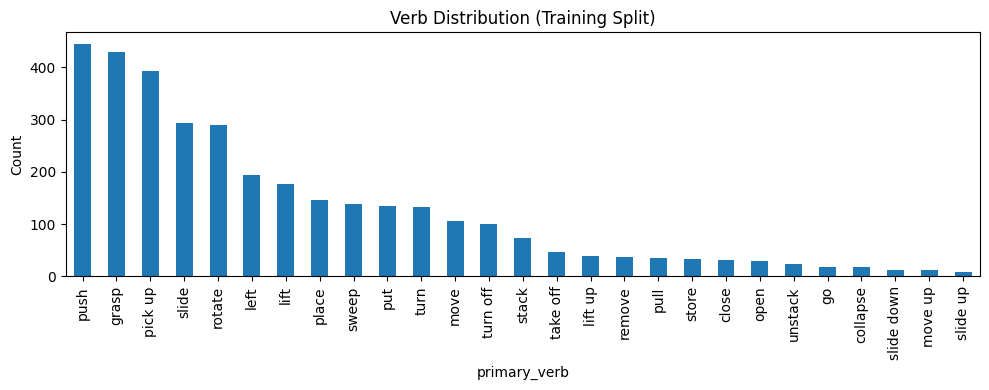

In [3]:
verb_counts = df['primary_verb'].value_counts()
print(verb_counts)
print()

fig, ax = plt.subplots(figsize=(10, 4))
verb_counts.plot.bar(ax=ax)
ax.set_ylabel("Count")
ax.set_title("Verb Distribution (Training Split)")
plt.tight_layout()
plt.show()

## 3. Inspect a single episode file

In [4]:
sample_row = df.iloc[0]
sample_path = os.path.join(TRAIN_DIR, EPISODE_TEMPLATE.format(sample_row['start_idx']))
data = np.load(sample_path)

print("Keys in episode .npz file:")
for k in data.keys():
    print(f"  {k:20s} shape={str(data[k].shape):20s} dtype={data[k].dtype}")

Keys in episode .npz file:
  actions              shape=(7,)                 dtype=float64
  rel_actions          shape=(7,)                 dtype=float64
  robot_obs            shape=(15,)                dtype=float64
  scene_obs            shape=(24,)                dtype=float64
  rgb_static           shape=(200, 200, 3)        dtype=uint8
  rgb_gripper          shape=(84, 84, 3)          dtype=uint8
  rgb_tactile          shape=(160, 120, 6)        dtype=uint8
  depth_static         shape=(200, 200)           dtype=float32
  depth_gripper        shape=(84, 84)             dtype=float32
  depth_tactile        shape=(160, 120, 2)        dtype=float32


## 4. Visualize first & last frames for a few episodes

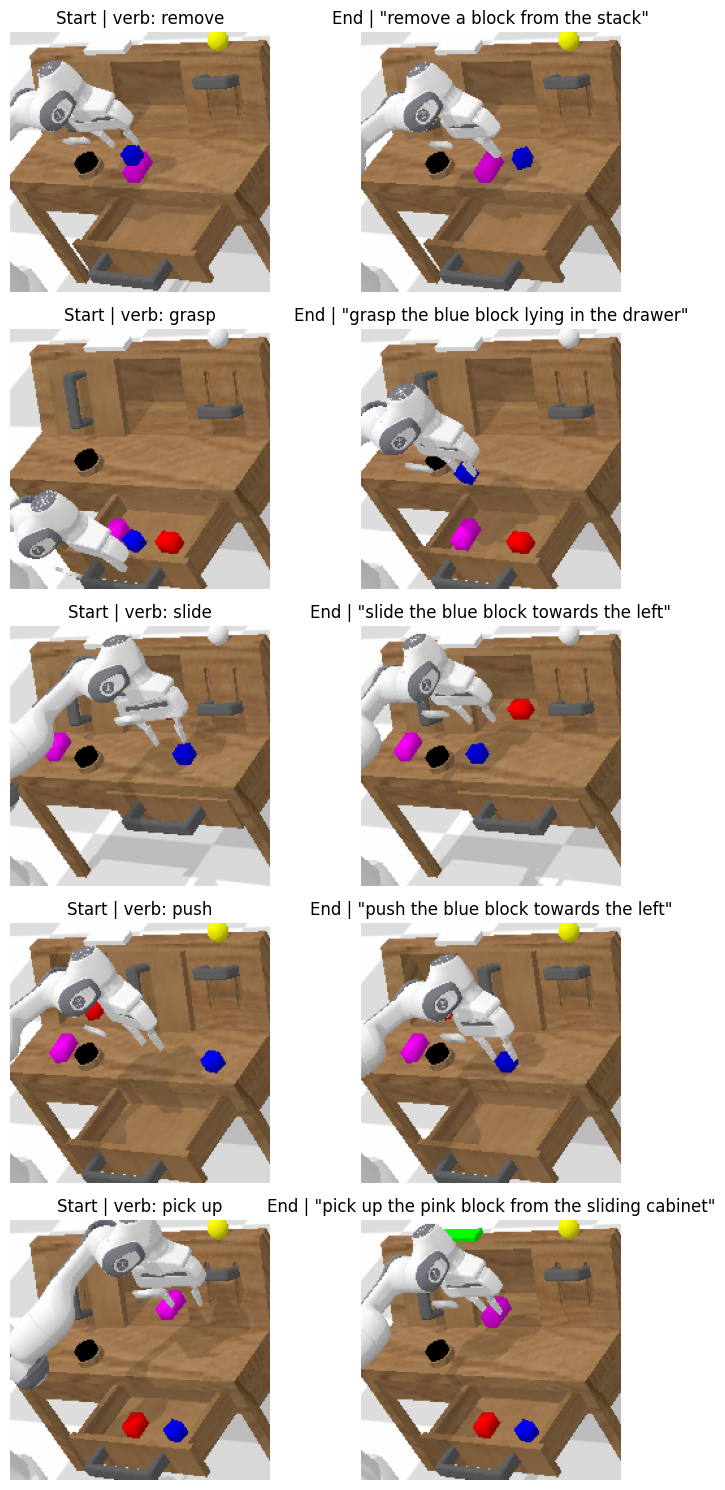

In [ ]:
num_samples = 5
samples = df.sample(num_samples, random_state=42)

fig, axes = plt.subplots(num_samples, 2, figsize=(8, 3 * num_samples))

for i, (_, row) in enumerate(samples.iterrows()):
    start_img = np.load(os.path.join(TRAIN_DIR, EPISODE_TEMPLATE.format(row['start_idx'])))[IMAGE_KEY]
    end_img = np.load(os.path.join(TRAIN_DIR, EPISODE_TEMPLATE.format(row['end_idx'])))[IMAGE_KEY]

    axes[i, 0].imshow(start_img)
    axes[i, 0].set_title(f"Start | verb: {row['primary_verb']}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(end_img)
    axes[i, 1].set_title(f"End | \"{row['instruction']}\"")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()



## 5. Plot action trajectories for those same episodes
Each trajectory is a sequence of 7D relative actions (dx, dy, dz, droll, dpitch, dyaw, gripper).

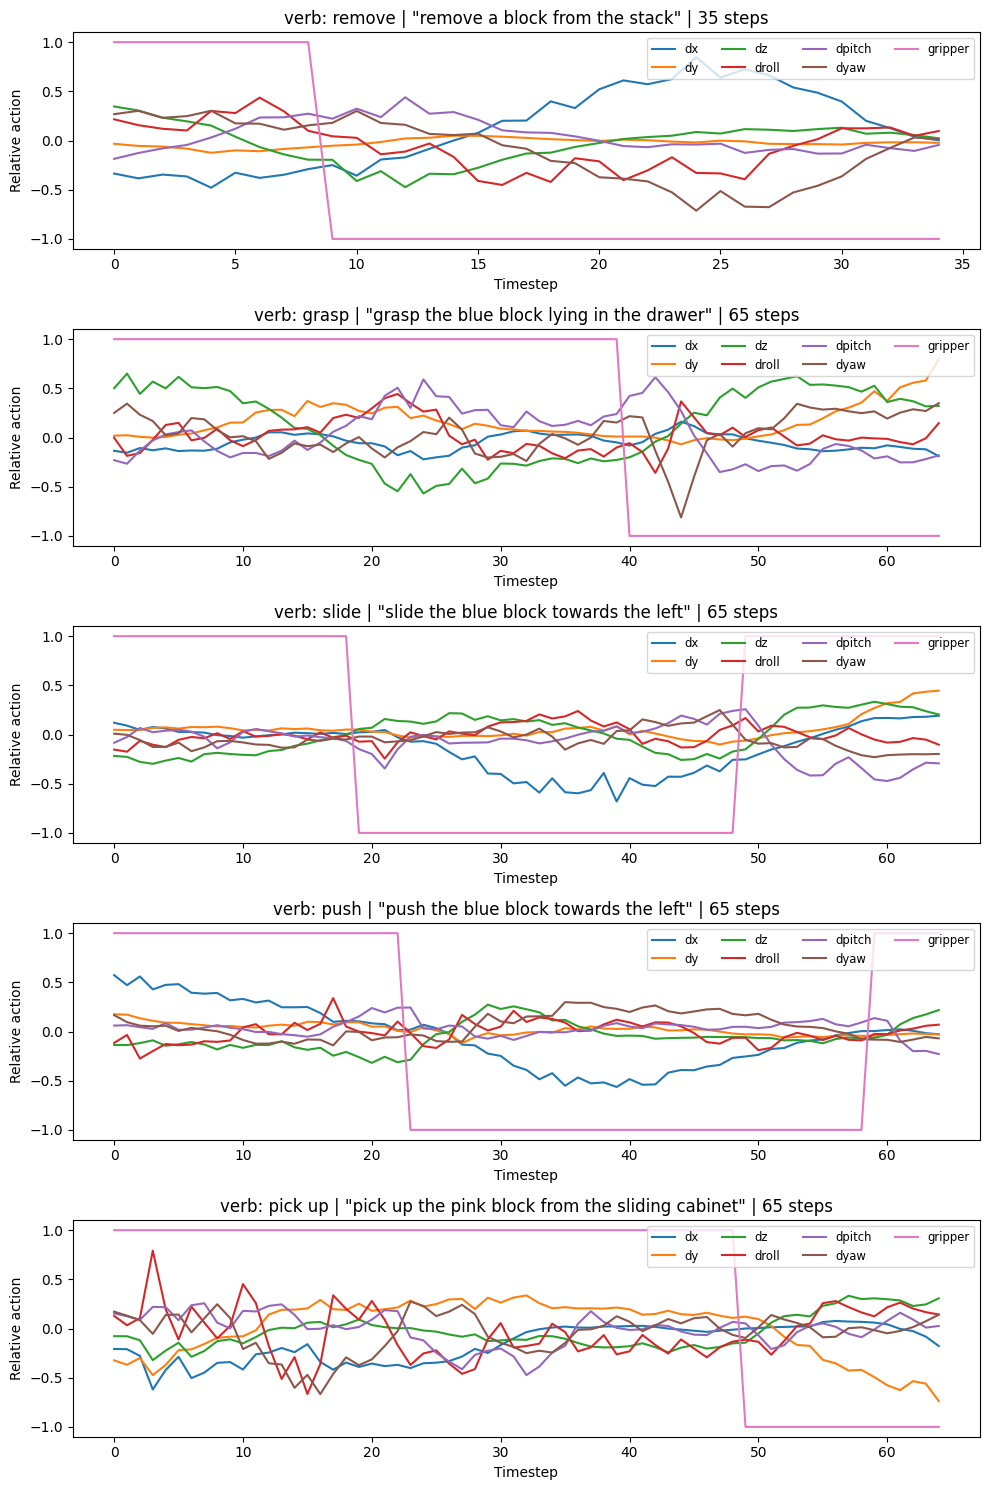

In [6]:
action_labels = ["dx", "dy", "dz", "droll", "dpitch", "dyaw", "gripper"]

fig, axes = plt.subplots(num_samples, 1, figsize=(10, 3 * num_samples))

for i, (_, row) in enumerate(samples.iterrows()):
    actions = []
    for idx in range(row['start_idx'], row['end_idx'] + 1):
        ep = np.load(os.path.join(TRAIN_DIR, EPISODE_TEMPLATE.format(idx)))
        actions.append(ep[ACTION_KEY])
    actions = np.array(actions)

    for dim in range(actions.shape[1]):
        axes[i].plot(actions[:, dim], label=action_labels[dim])
    axes[i].set_title(f"verb: {row['primary_verb']} | \"{row['instruction']}\" | {len(actions)} steps")
    axes[i].set_xlabel("Timestep")
    axes[i].set_ylabel("Relative action")
    axes[i].legend(loc="upper right", fontsize="small", ncol=4)

plt.tight_layout()
plt.show()

## 6. Sequence length distribution

Sequence length stats:
count    3404.000000
mean       59.877791
std         9.927376
min        34.000000
25%        65.000000
50%        65.000000
75%        65.000000
max        65.000000
Name: seq_len, dtype: float64



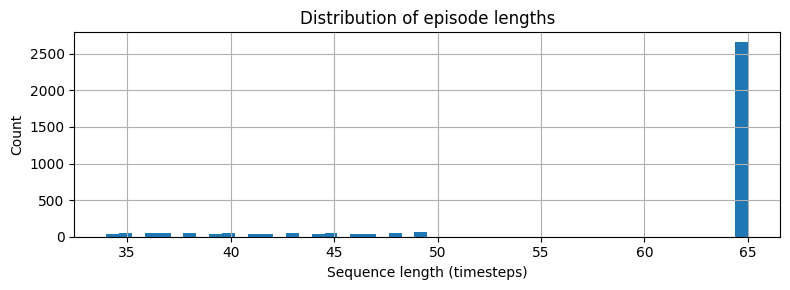

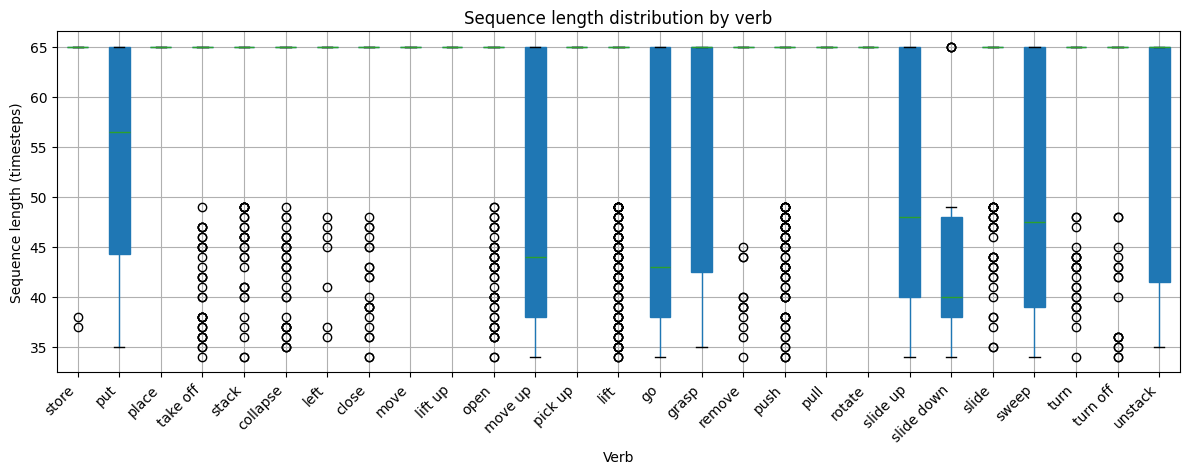

In [9]:
df['seq_len'] = df['end_idx'] - df['start_idx'] + 1

print(f"Sequence length stats:")
print(df['seq_len'].describe())
print()

fig, ax = plt.subplots(figsize=(8, 3))
df['seq_len'].hist(bins=50, ax=ax)
ax.set_xlabel("Sequence length (timesteps)")
ax.set_ylabel("Count")
ax.set_title("Distribution of episode lengths")
plt.tight_layout()
plt.show()

# Box plot of sequence length per verb
verb_order = df.groupby('primary_verb')['seq_len'].median().sort_values().index
fig, ax = plt.subplots(figsize=(12, 5))
df.boxplot(column='seq_len', by='primary_verb', ax=ax,
           positions=range(len(verb_order)),
           showfliers=True, patch_artist=True)
ax.set_xticklabels(verb_order, rotation=45, ha='right')
ax.set_xlabel("Verb")
ax.set_ylabel("Sequence length (timesteps)")
ax.set_title("Sequence length distribution by verb")
fig.suptitle("")  # remove default pandas boxplot title
plt.tight_layout()
plt.show()